## Semantic vs. Sentiment: ROC Curve
This graph compares the Receiver Operating Characteristic (ROC) curves for semantic and sentiment analyses. The ROC curve is a graphical representation of the true positive rate against the false positive rate, illustrating the performance of each model in sockpuppet detection.

Training SVM for Semantic Analysis...
Training Random Forest for Sentiment Analysis...


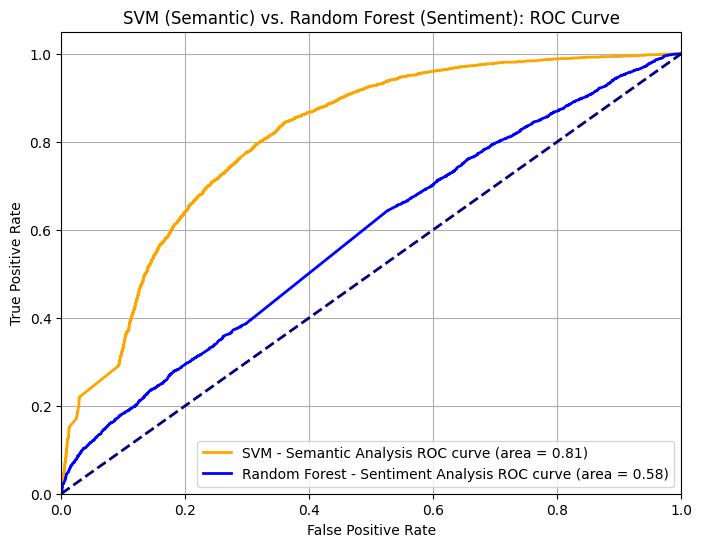

In [2]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc
from textblob import TextBlob

# Load the Wikipedia dataset
data = pd.read_csv('wikipedia_sockpuppet_dataset_CLEANED.csv')

# Preprocessing function
def preprocess(text):
    # Convert text to lowercase
    text = text.lower()
    return text

# Applying preprocessing to the edit text
data['processed_edit_text'] = data['edit_text'].apply(preprocess)

# Semantic Analysis using TF-IDF
# SVM is used for Semantic Analysis
tfidf = TfidfVectorizer(max_features=1000)
X_semantic = tfidf.fit_transform(data['processed_edit_text']).toarray()

# Sentiment Analysis
# Random Forest is used for Sentiment Analysis
data['polarity'], data['subjectivity'] = zip(*data['edit_text'].apply(lambda text: (TextBlob(text).sentiment.polarity, TextBlob(text).sentiment.subjectivity)))
X_sentiment = data[['polarity', 'subjectivity']]

# Labels for the dataset
y = data['is_sockpuppet']

# Splitting the dataset for semantic analysis
X_train_semantic, X_test_semantic, y_train, y_test = train_test_split(X_semantic, y, test_size=0.2, stratify=y, random_state=42)

# Model Training using SVM for semantic analysis
print("Training SVM for Semantic Analysis...")
model_semantic = SVC(probability=True, random_state=42)
model_semantic.fit(X_train_semantic, y_train)

# Splitting the dataset for sentiment analysis
X_train_sentiment, X_test_sentiment, y_train_sentiment, y_test_sentiment = train_test_split(X_sentiment, y, test_size=0.2, stratify=y, random_state=42)

# Model Training using Random Forest for sentiment analysis
print("Training Random Forest for Sentiment Analysis...")
model_sentiment = RandomForestClassifier(n_estimators=100, random_state=42)
model_sentiment.fit(X_train_sentiment, y_train_sentiment)

# Get predicted probabilities for the test set for both models
y_proba_semantic = model_semantic.predict_proba(X_test_semantic)[:, 1]
y_proba_sentiment = model_sentiment.predict_proba(X_test_sentiment)[:, 1]

# Compute ROC curve and ROC area for both models
fpr_semantic, tpr_semantic, _ = roc_curve(y_test, y_proba_semantic)
roc_auc_semantic = auc(fpr_semantic, tpr_semantic)

fpr_sentiment, tpr_sentiment, _ = roc_curve(y_test, y_proba_sentiment)
roc_auc_sentiment = auc(fpr_sentiment, tpr_sentiment)

# Plot the overlaid ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_semantic, tpr_semantic, color='orange', lw=2, label='SVM - Semantic Analysis ROC curve (area = %0.2f)' % roc_auc_semantic)
plt.plot(fpr_sentiment, tpr_sentiment, color='blue', lw=2, label='Random Forest - Sentiment Analysis ROC curve (area = %0.2f)' % roc_auc_sentiment)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM (Semantic) vs. Random Forest (Sentiment): ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Semantic vs. Sentiment: PR Curve
This visualization shows the Precision-Recall (PR) curves for semantic and sentiment analyses. The PR curve demonstrates the trade-off between precision and recall for each analysis type, providing insight into their effectiveness in identifying sockpuppets.

Training SVM for Semantic Analysis...
Training Random Forest for Sentiment Analysis...


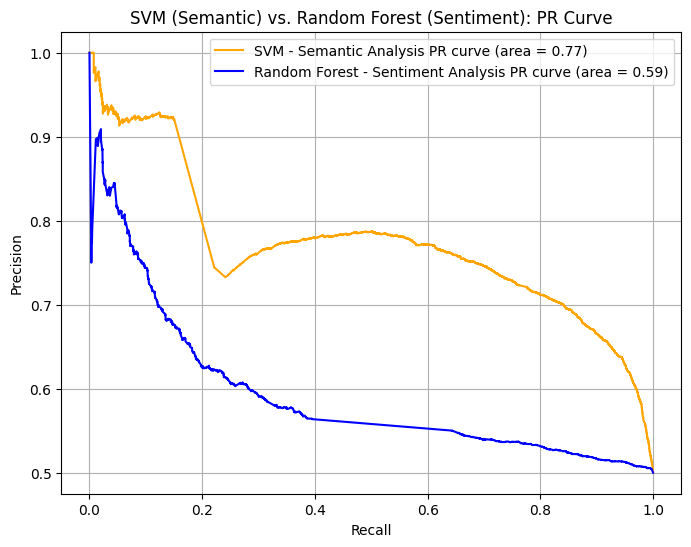

In [3]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_curve, auc
from textblob import TextBlob
import matplotlib.pyplot as plt

# Load the training and testing datasets
train_data = pd.read_csv('wikipedia_sockpuppet_dataset_TRAIN.csv')
test_data = pd.read_csv('wikipedia_sockpuppet_dataset_TEST.csv')

# Preprocessing function
def preprocess(text):
    text = text.lower()
    return text

# Preprocess text data in both training and testing sets
train_data['processed_edit_text'] = train_data['edit_text'].apply(preprocess)
test_data['processed_edit_text'] = test_data['edit_text'].apply(preprocess)

# Semantic Analysis using TF-IDF
# SVM is used for Semantic Analysis
tfidf = TfidfVectorizer(max_features=1000)
X_train_semantic = tfidf.fit_transform(train_data['processed_edit_text']).toarray()
X_test_semantic = tfidf.transform(test_data['processed_edit_text']).toarray()

# Sentiment Analysis
# Random Forest is used for Sentiment Analysis
train_data['polarity'], train_data['subjectivity'] = zip(*train_data['processed_edit_text'].apply(lambda text: (TextBlob(text).sentiment.polarity, TextBlob(text).sentiment.subjectivity)))
test_data['polarity'], test_data['subjectivity'] = zip(*test_data['processed_edit_text'].apply(lambda text: (TextBlob(text).sentiment.polarity, TextBlob(text).sentiment.subjectivity)))

X_train_sentiment = np.array(train_data[['polarity', 'subjectivity']])
X_test_sentiment = np.array(test_data[['polarity', 'subjectivity']])

# Labels for the datasets
y_train = train_data['is_sockpuppet']
y_test = test_data['is_sockpuppet']

# Model Training using SVM for semantic analysis
print("Training SVM for Semantic Analysis...")
model_semantic = SVC(probability=True, random_state=42)
model_semantic.fit(X_train_semantic, y_train)

# Predictions for semantic analysis
y_score_semantic = model_semantic.predict_proba(X_test_semantic)[:, 1]

# Model Training using Random Forest for sentiment analysis
print("Training Random Forest for Sentiment Analysis...")
model_sentiment = RandomForestClassifier(n_estimators=100, random_state=42)
model_sentiment.fit(X_train_sentiment, y_train)

# Predictions for sentiment analysis
y_score_sentiment = model_sentiment.predict_proba(X_test_sentiment)[:, 1]

# Calculate Precision-Recall curve and AUC
precision_semantic, recall_semantic, _ = precision_recall_curve(y_test, y_score_semantic)
pr_auc_semantic = auc(recall_semantic, precision_semantic)
precision_sentiment, recall_sentiment, _ = precision_recall_curve(y_test, y_score_sentiment)
pr_auc_sentiment = auc(recall_sentiment, precision_sentiment)

# Plotting Precision-Recall curves
plt.figure(figsize=(8, 6))
plt.plot(recall_semantic, precision_semantic, color='orange', label='SVM - Semantic Analysis PR curve (area = %.2f)' % pr_auc_semantic)
plt.plot(recall_sentiment, precision_sentiment, color='blue', label='Random Forest - Sentiment Analysis PR curve (area = %.2f)' % pr_auc_sentiment)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('SVM (Semantic) vs. Random Forest (Sentiment): PR Curve')
plt.legend()
plt.grid(True)
plt.show()


## Combined Analysis: ROC Curve
The ROC curve compares the combined semantic and sentiment analysis with the individual semantic and sentiment analyses. It displays the true positive rate against the false positive rate, showcasing how the combined approach and each individual method perform in sockpuppet detection.

Training SVM for Semantic Analysis...
Training Random Forest for Sentiment Analysis...
Training Combined Model using SVM and Random Forest...


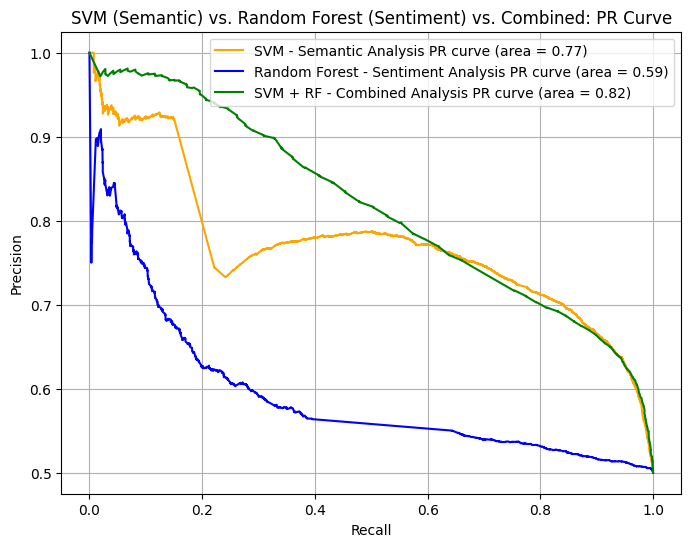

In [4]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_curve, auc
from textblob import TextBlob
import matplotlib.pyplot as plt

# Load the training and testing datasets
train_data = pd.read_csv('wikipedia_sockpuppet_dataset_TRAIN.csv')
test_data = pd.read_csv('wikipedia_sockpuppet_dataset_TEST.csv')

# Preprocessing function
def preprocess(text):
    text = text.lower()
    return text

# Preprocess text data in both training and testing sets
train_data['processed_edit_text'] = train_data['edit_text'].apply(preprocess)
test_data['processed_edit_text'] = test_data['edit_text'].apply(preprocess)

# Semantic Analysis using TF-IDF
# SVM is used for Semantic Analysis
tfidf = TfidfVectorizer(max_features=1000)
X_train_semantic = tfidf.fit_transform(train_data['processed_edit_text']).toarray()
X_test_semantic = tfidf.transform(test_data['processed_edit_text']).toarray()

# Sentiment Analysis
# Random Forest is used for Sentiment Analysis
train_data['polarity'], train_data['subjectivity'] = zip(*train_data['processed_edit_text'].apply(lambda text: (TextBlob(text).sentiment.polarity, TextBlob(text).sentiment.subjectivity)))
test_data['polarity'], test_data['subjectivity'] = zip(*test_data['processed_edit_text'].apply(lambda text: (TextBlob(text).sentiment.polarity, TextBlob(text).sentiment.subjectivity)))

X_train_sentiment = np.array(train_data[['polarity', 'subjectivity']])
X_test_sentiment = np.array(test_data[['polarity', 'subjectivity']])

# Combined Features (Semantic + Sentiment)
X_train_combined = np.hstack((X_train_semantic, X_train_sentiment))
X_test_combined = np.hstack((X_test_semantic, X_test_sentiment))

# Labels for the datasets
y_train = train_data['is_sockpuppet']
y_test = test_data['is_sockpuppet']

# Model Training using SVM for semantic analysis
print("Training SVM for Semantic Analysis...")
model_semantic = SVC(probability=True, random_state=42)
model_semantic.fit(X_train_semantic, y_train)

# Predictions for semantic analysis
y_score_semantic = model_semantic.predict_proba(X_test_semantic)[:, 1]

# Model Training using Random Forest for sentiment analysis
print("Training Random Forest for Sentiment Analysis...")
model_sentiment = RandomForestClassifier(n_estimators=100, random_state=42)
model_sentiment.fit(X_train_sentiment, y_train)

# Predictions for sentiment analysis
y_score_sentiment = model_sentiment.predict_proba(X_test_sentiment)[:, 1]

# Model Training using SVM and Random Forest for combined analysis
print("Training Combined Model using SVM and Random Forest...")
model_combined = RandomForestClassifier(n_estimators=100, random_state=42)
model_combined.fit(X_train_combined, y_train)

# Predictions for combined analysis
y_score_combined = model_combined.predict_proba(X_test_combined)[:, 1]

# Calculate Precision-Recall curve and AUC
precision_semantic, recall_semantic, _ = precision_recall_curve(y_test, y_score_semantic)
pr_auc_semantic = auc(recall_semantic, precision_semantic)
precision_sentiment, recall_sentiment, _ = precision_recall_curve(y_test, y_score_sentiment)
pr_auc_sentiment = auc(recall_sentiment, precision_sentiment)
precision_combined, recall_combined, _ = precision_recall_curve(y_test, y_score_combined)
pr_auc_combined = auc(recall_combined, precision_combined)

# Plotting Precision-Recall curves
plt.figure(figsize=(8, 6))
plt.plot(recall_semantic, precision_semantic, color='orange', label='SVM - Semantic Analysis PR curve (area = %.2f)' % pr_auc_semantic)
plt.plot(recall_sentiment, precision_sentiment, color='blue', label='Random Forest - Sentiment Analysis PR curve (area = %.2f)' % pr_auc_sentiment)
plt.plot(recall_combined, precision_combined, color='green', label='SVM + RF - Combined Analysis PR curve (area = %.2f)' % pr_auc_combined)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('SVM (Semantic) vs. Random Forest (Sentiment) vs. Combined: PR Curve')
plt.legend()
plt.grid(True)
plt.show()

## Combined Analysis: PR Curve
This PR curve compares the combined semantic and sentiment analysis with the individual semantic and sentiment analyses. It evaluates the precision and recall for each method, showing the effectiveness and differences between combined and individual analyses in detecting sockpuppets.

Training SVM for Semantic Analysis...
Training Random Forest for Sentiment Analysis...
Training Combined Model using SVM and Random Forest...


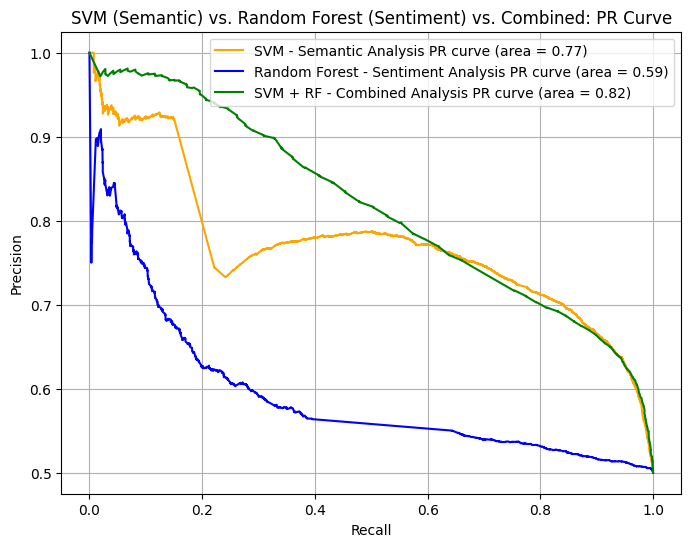

In [5]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_curve, auc
from textblob import TextBlob
import matplotlib.pyplot as plt

# Load the training and testing datasets
train_data = pd.read_csv('wikipedia_sockpuppet_dataset_TRAIN.csv')
test_data = pd.read_csv('wikipedia_sockpuppet_dataset_TEST.csv')

# Preprocessing function
def preprocess(text):
    text = text.lower()
    return text

# Preprocess text data in both training and testing sets
train_data['processed_edit_text'] = train_data['edit_text'].apply(preprocess)
test_data['processed_edit_text'] = test_data['edit_text'].apply(preprocess)

# Semantic Analysis using TF-IDF
# SVM is used for Semantic Analysis
tfidf = TfidfVectorizer(max_features=1000)
X_train_semantic = tfidf.fit_transform(train_data['processed_edit_text']).toarray()
X_test_semantic = tfidf.transform(test_data['processed_edit_text']).toarray()

# Sentiment Analysis
# Random Forest is used for Sentiment Analysis
train_data['polarity'], train_data['subjectivity'] = zip(*train_data['processed_edit_text'].apply(lambda text: (TextBlob(text).sentiment.polarity, TextBlob(text).sentiment.subjectivity)))
test_data['polarity'], test_data['subjectivity'] = zip(*test_data['processed_edit_text'].apply(lambda text: (TextBlob(text).sentiment.polarity, TextBlob(text).sentiment.subjectivity)))

X_train_sentiment = np.array(train_data[['polarity', 'subjectivity']])
X_test_sentiment = np.array(test_data[['polarity', 'subjectivity']])

# Combined Features (Semantic + Sentiment)
X_train_combined = np.hstack((X_train_semantic, X_train_sentiment))
X_test_combined = np.hstack((X_test_semantic, X_test_sentiment))

# Labels for the datasets
y_train = train_data['is_sockpuppet']
y_test = test_data['is_sockpuppet']

# Model Training using SVM for semantic analysis
print("Training SVM for Semantic Analysis...")
model_semantic = SVC(probability=True, random_state=42)
model_semantic.fit(X_train_semantic, y_train)

# Predictions for semantic analysis
y_score_semantic = model_semantic.predict_proba(X_test_semantic)[:, 1]

# Model Training using Random Forest for sentiment analysis
print("Training Random Forest for Sentiment Analysis...")
model_sentiment = RandomForestClassifier(n_estimators=100, random_state=42)
model_sentiment.fit(X_train_sentiment, y_train)

# Predictions for sentiment analysis
y_score_sentiment = model_sentiment.predict_proba(X_test_sentiment)[:, 1]

# Model Training using SVM and Random Forest for combined analysis
print("Training Combined Model using SVM and Random Forest...")
model_combined = RandomForestClassifier(n_estimators=100, random_state=42)
model_combined.fit(X_train_combined, y_train)

# Predictions for combined analysis
y_score_combined = model_combined.predict_proba(X_test_combined)[:, 1]

# Calculate Precision-Recall curve and AUC
precision_semantic, recall_semantic, _ = precision_recall_curve(y_test, y_score_semantic)
pr_auc_semantic = auc(recall_semantic, precision_semantic)
precision_sentiment, recall_sentiment, _ = precision_recall_curve(y_test, y_score_sentiment)
pr_auc_sentiment = auc(recall_sentiment, precision_sentiment)
precision_combined, recall_combined, _ = precision_recall_curve(y_test, y_score_combined)
pr_auc_combined = auc(recall_combined, precision_combined)

# Plotting Precision-Recall curves
plt.figure(figsize=(8, 6))
plt.plot(recall_semantic, precision_semantic, color='orange', label='SVM - Semantic Analysis PR curve (area = %.2f)' % pr_auc_semantic)
plt.plot(recall_sentiment, precision_sentiment, color='blue', label='Random Forest - Sentiment Analysis PR curve (area = %.2f)' % pr_auc_sentiment)
plt.plot(recall_combined, precision_combined, color='green', label='SVM + RF - Combined Analysis PR curve (area = %.2f)' % pr_auc_combined)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('SVM (Semantic) vs. Random Forest (Sentiment) vs. Combined: PR Curve')
plt.legend()
plt.grid(True)
plt.show()


## Combined Analysis: Confusion Matrix
The confusion matrix for the combined analysis of semantic and sentiment features is shown, detailing the number of true positives, true negatives, false positives, and false negatives, providing a comprehensive view of the model's classification accuracy.

Training SVM for Semantic Analysis...
Training Random Forest for Sentiment Analysis...
Training Combined Model using SVM and Random Forest...


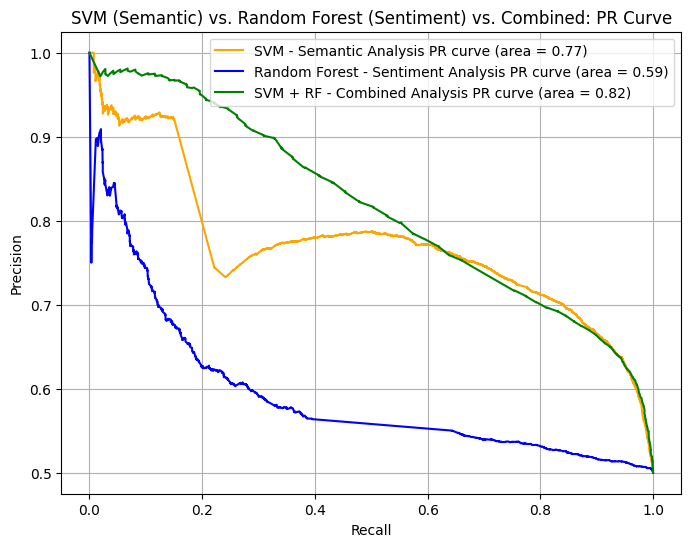

In [6]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_curve, auc
from textblob import TextBlob
import matplotlib.pyplot as plt

# Load the training and testing datasets
train_data = pd.read_csv('wikipedia_sockpuppet_dataset_TRAIN.csv')
test_data = pd.read_csv('wikipedia_sockpuppet_dataset_TEST.csv')

# Preprocessing function
def preprocess(text):
    text = text.lower()
    return text

# Preprocess text data in both training and testing sets
train_data['processed_edit_text'] = train_data['edit_text'].apply(preprocess)
test_data['processed_edit_text'] = test_data['edit_text'].apply(preprocess)

# Semantic Analysis using TF-IDF
# SVM is used for Semantic Analysis
tfidf = TfidfVectorizer(max_features=1000)
X_train_semantic = tfidf.fit_transform(train_data['processed_edit_text']).toarray()
X_test_semantic = tfidf.transform(test_data['processed_edit_text']).toarray()

# Sentiment Analysis
# Random Forest is used for Sentiment Analysis
train_data['polarity'], train_data['subjectivity'] = zip(*train_data['processed_edit_text'].apply(lambda text: (TextBlob(text).sentiment.polarity, TextBlob(text).sentiment.subjectivity)))
test_data['polarity'], test_data['subjectivity'] = zip(*test_data['processed_edit_text'].apply(lambda text: (TextBlob(text).sentiment.polarity, TextBlob(text).sentiment.subjectivity)))

X_train_sentiment = np.array(train_data[['polarity', 'subjectivity']])
X_test_sentiment = np.array(test_data[['polarity', 'subjectivity']])

# Combined Features (Semantic + Sentiment)
X_train_combined = np.hstack((X_train_semantic, X_train_sentiment))
X_test_combined = np.hstack((X_test_semantic, X_test_sentiment))

# Labels for the datasets
y_train = train_data['is_sockpuppet']
y_test = test_data['is_sockpuppet']

# Model Training using SVM for semantic analysis
print("Training SVM for Semantic Analysis...")
model_semantic = SVC(probability=True, random_state=42)
model_semantic.fit(X_train_semantic, y_train)

# Predictions for semantic analysis
y_score_semantic = model_semantic.predict_proba(X_test_semantic)[:, 1]

# Model Training using Random Forest for sentiment analysis
print("Training Random Forest for Sentiment Analysis...")
model_sentiment = RandomForestClassifier(n_estimators=100, random_state=42)
model_sentiment.fit(X_train_sentiment, y_train)

# Predictions for sentiment analysis
y_score_sentiment = model_sentiment.predict_proba(X_test_sentiment)[:, 1]

# Model Training using SVM and Random Forest for combined analysis
print("Training Combined Model using SVM and Random Forest...")
model_combined = RandomForestClassifier(n_estimators=100, random_state=42)
model_combined.fit(X_train_combined, y_train)

# Predictions for combined analysis
y_score_combined = model_combined.predict_proba(X_test_combined)[:, 1]

# Calculate Precision-Recall curve and AUC
precision_semantic, recall_semantic, _ = precision_recall_curve(y_test, y_score_semantic)
pr_auc_semantic = auc(recall_semantic, precision_semantic)
precision_sentiment, recall_sentiment, _ = precision_recall_curve(y_test, y_score_sentiment)
pr_auc_sentiment = auc(recall_sentiment, precision_sentiment)
precision_combined, recall_combined, _ = precision_recall_curve(y_test, y_score_combined)
pr_auc_combined = auc(recall_combined, precision_combined)

# Plotting Precision-Recall curves
plt.figure(figsize=(8, 6))
plt.plot(recall_semantic, precision_semantic, color='orange', label='SVM - Semantic Analysis PR curve (area = %.2f)' % pr_auc_semantic)
plt.plot(recall_sentiment, precision_sentiment, color='blue', label='Random Forest - Sentiment Analysis PR curve (area = %.2f)' % pr_auc_sentiment)
plt.plot(recall_combined, precision_combined, color='green', label='SVM + RF - Combined Analysis PR curve (area = %.2f)' % pr_auc_combined)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('SVM (Semantic) vs. Random Forest (Sentiment) vs. Combined: PR Curve')
plt.legend()
plt.grid(True)
plt.show()
